# Lab Segmentation 1

In [6]:
from commonfunctions import *
%matplotlib inline
import skimage.io as io
from scipy.ndimage import binary_closing, binary_opening
from scipy.ndimage import generate_binary_structure
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


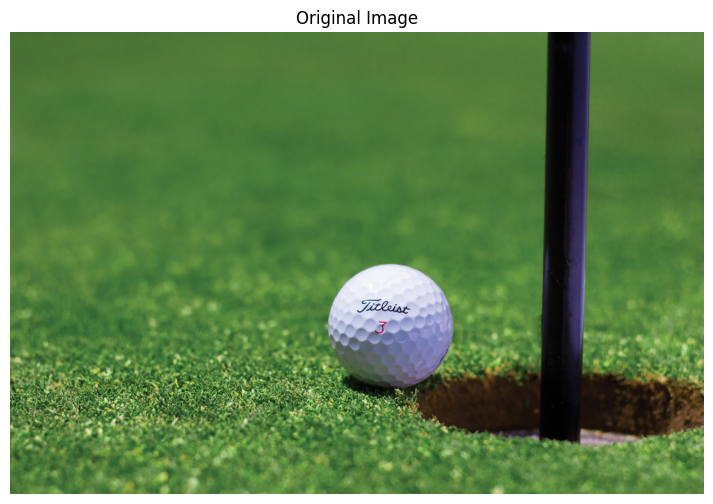

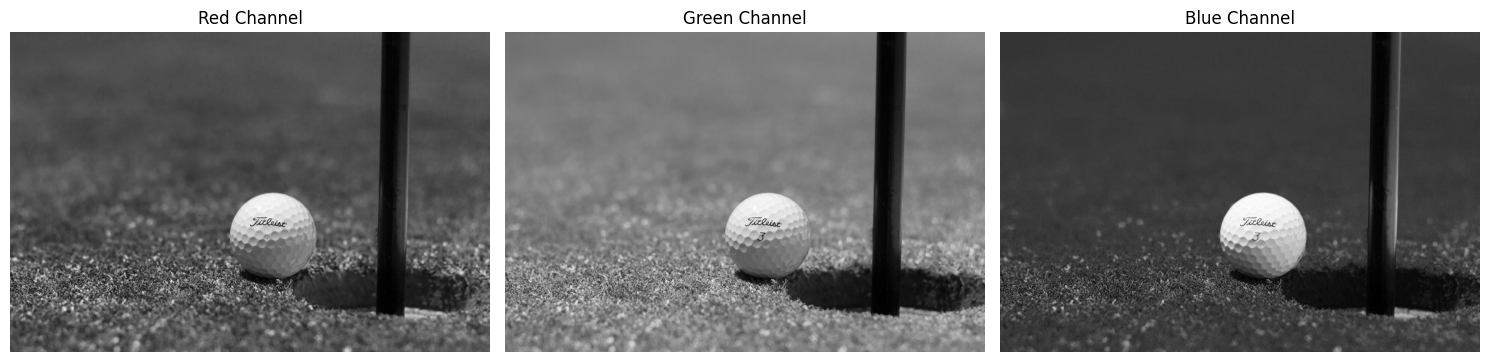

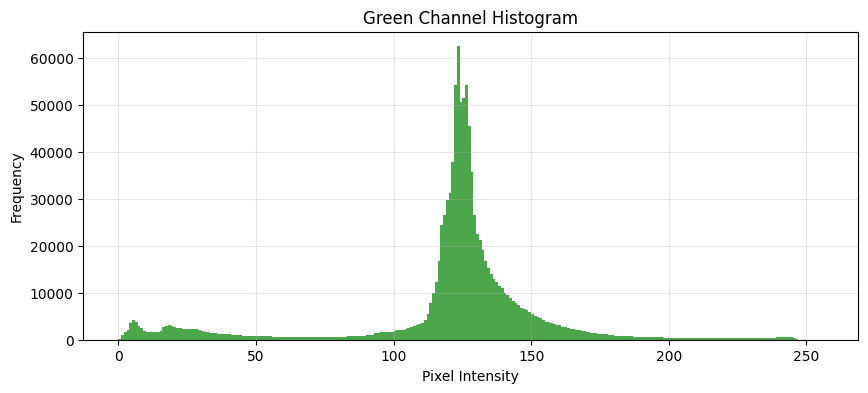

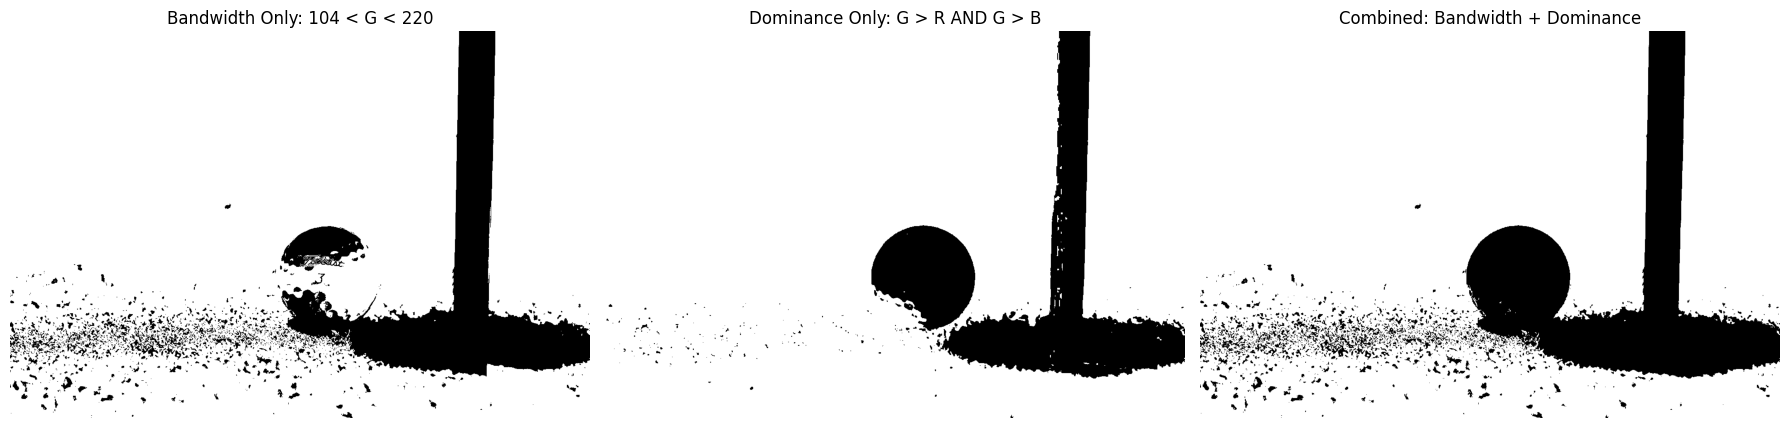

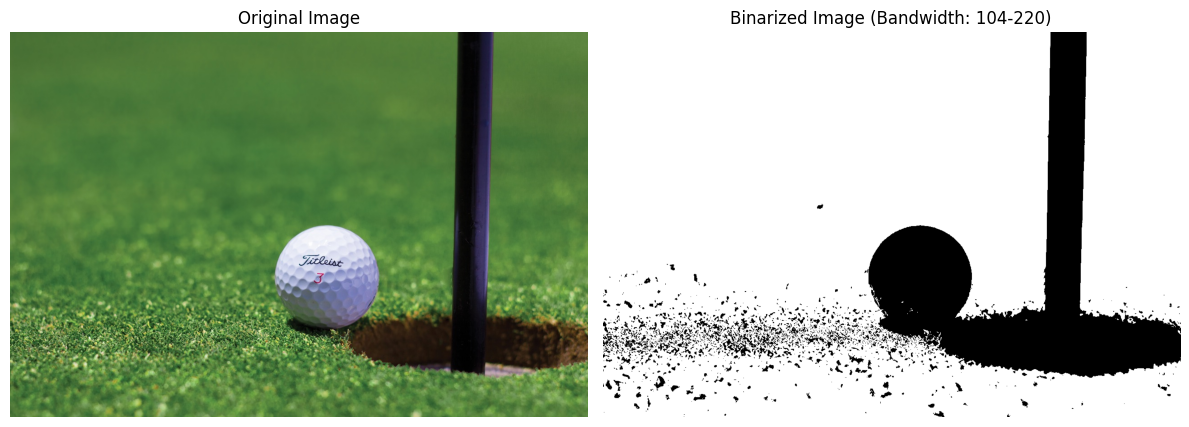

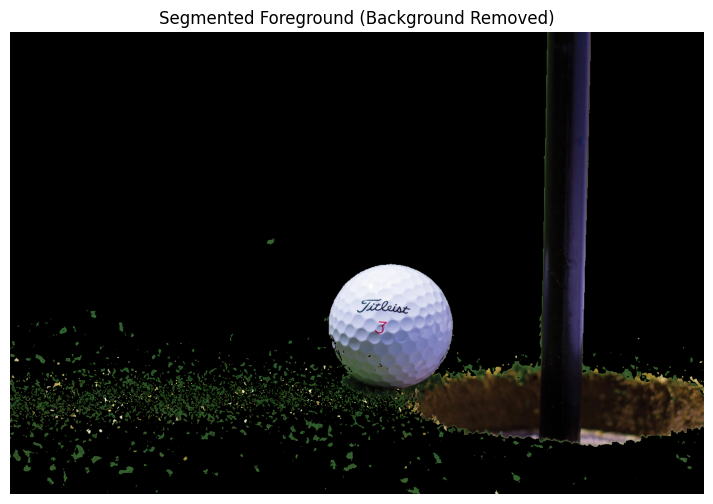

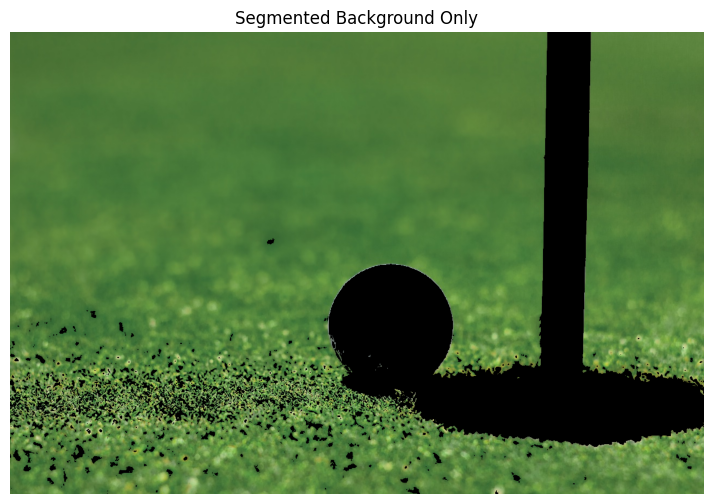

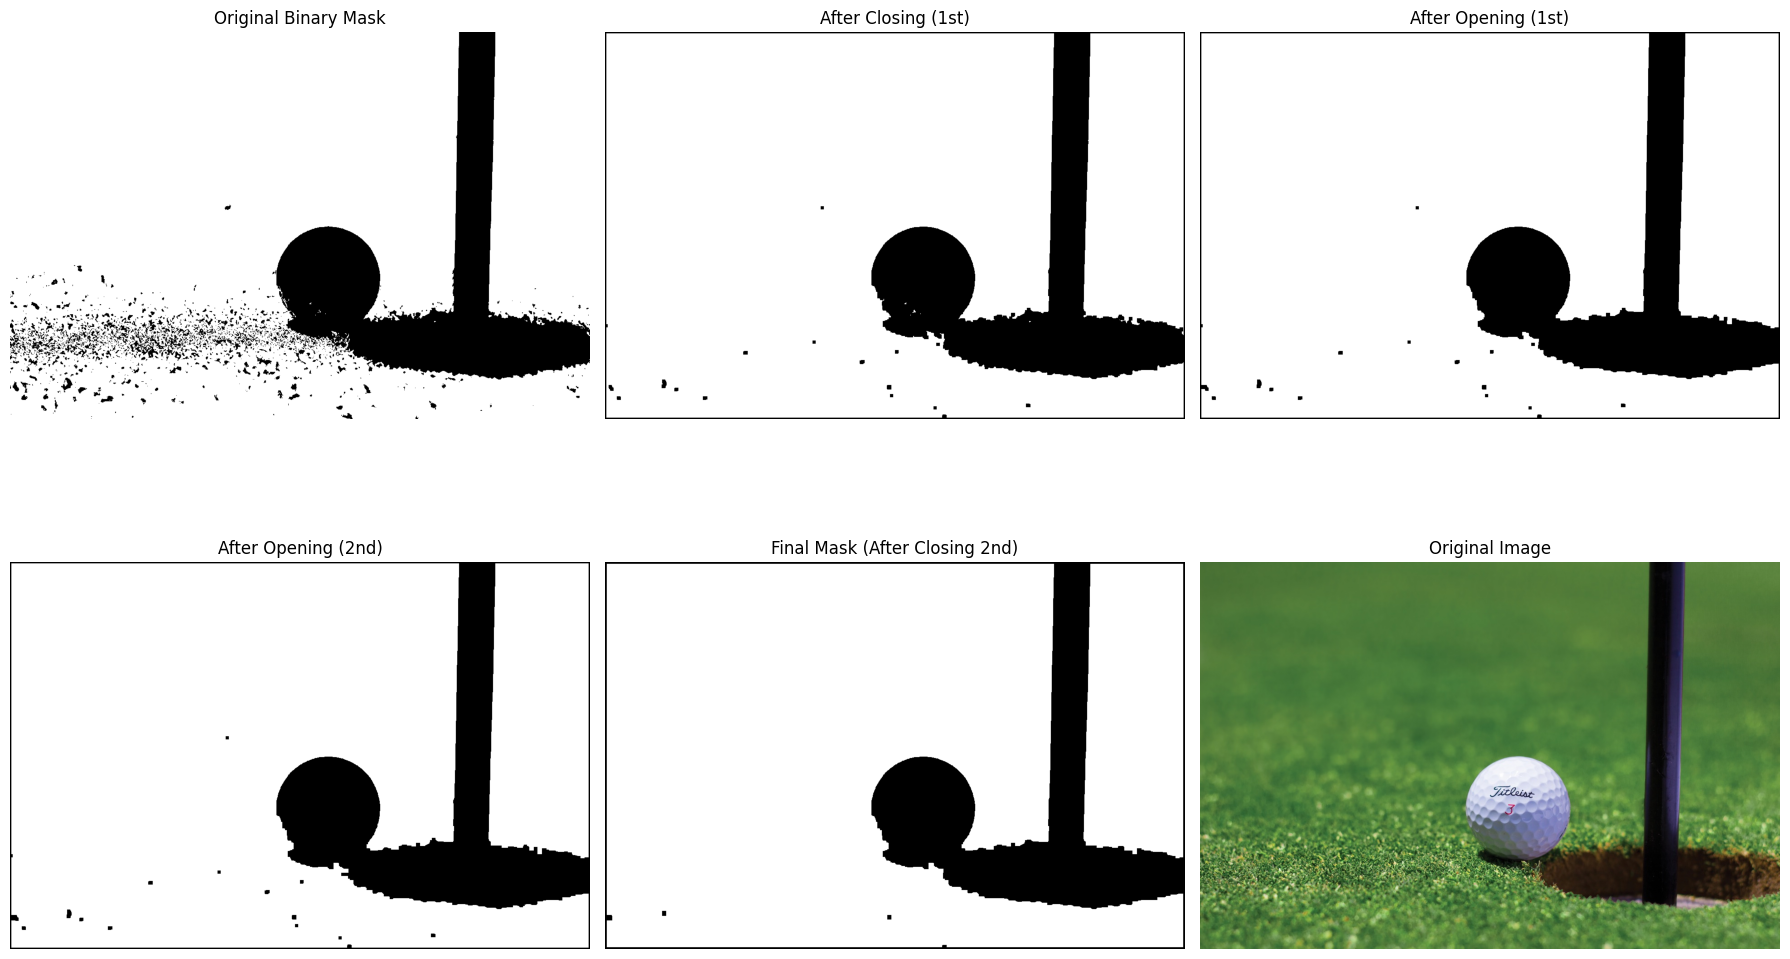

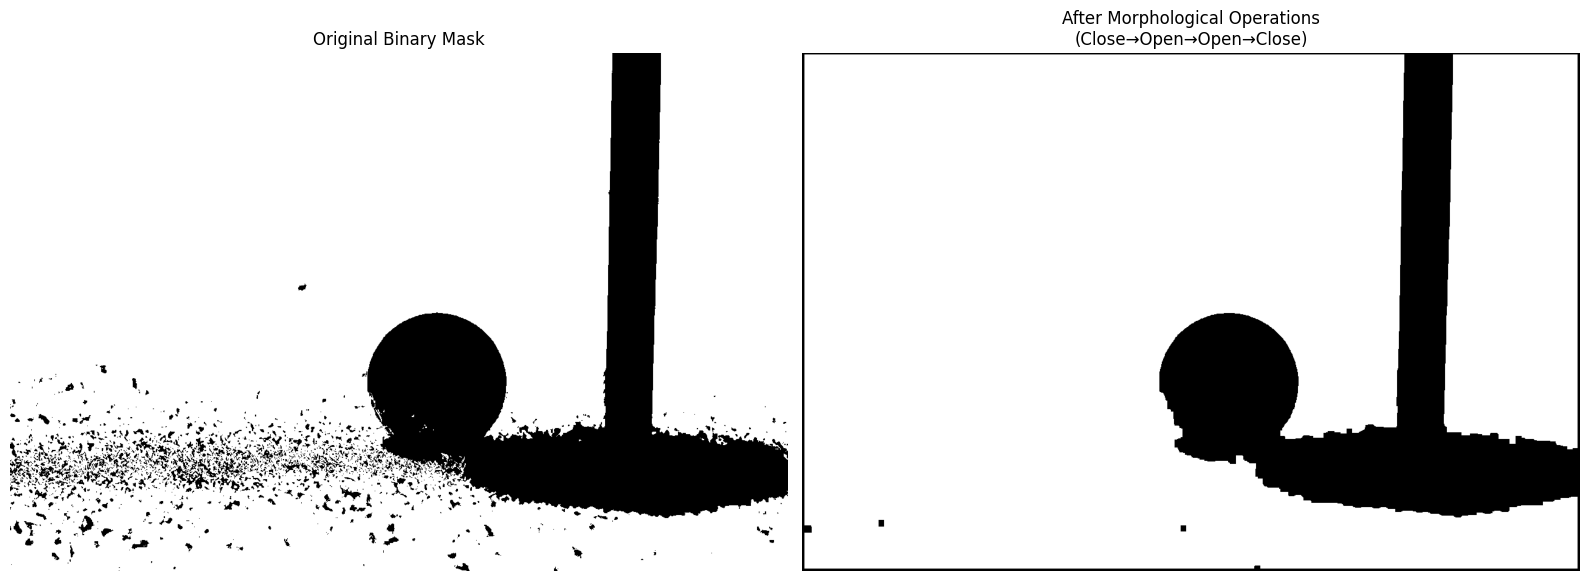

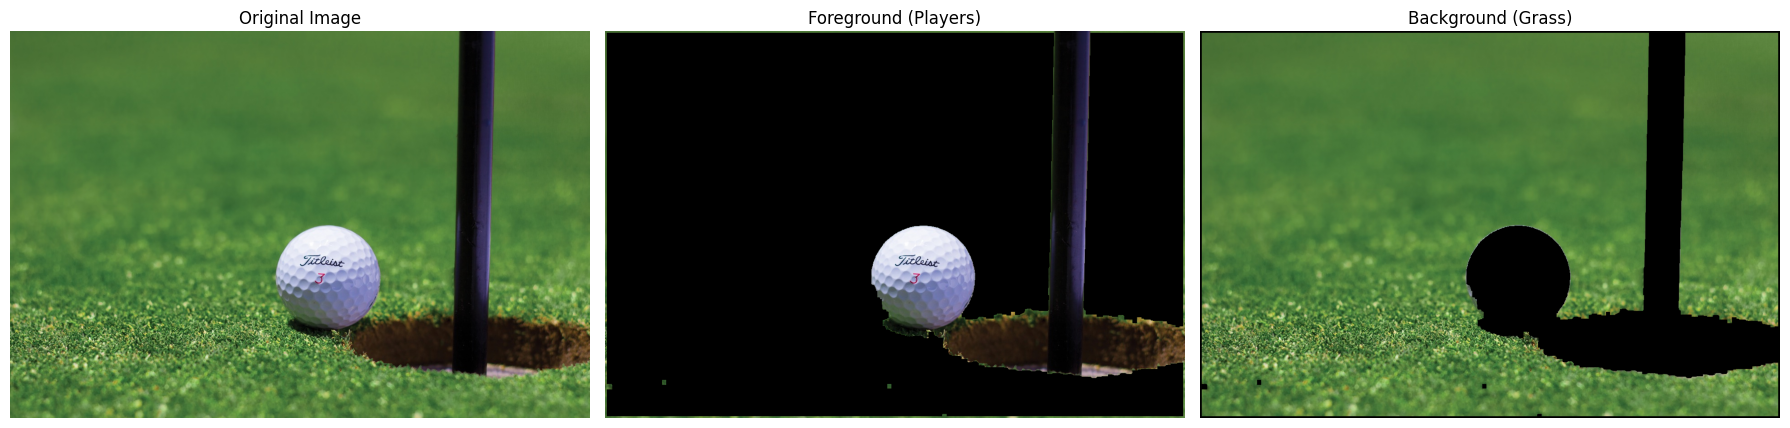

In [22]:

# [VERY IMPORTANT] and convert it to float: image = image.astype(float)
image = io.imread('imgs/exp1/golf.jpeg')
image = image.astype(float)

plt.figure(figsize=(10, 6))
plt.imshow(image.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')
plt.show()

R = image[:, :, 0]
G = image[:, :, 1]
B = image[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(R, cmap='gray')
axes[0].set_title('Red Channel')
axes[0].axis('off')

axes[1].imshow(G, cmap='gray')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(B, cmap='gray')
axes[2].set_title('Blue Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.hist(G.ravel(), bins=256, range=(0, 256), color='green', alpha=0.7)
plt.title('Green Channel Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()


# Choose optimal bandwidth
lower_threshold = 104
upper_threshold = 220

bandwidth_mask = (G > lower_threshold) & (G < upper_threshold)

combined_mask = bandwidth_mask & (G > R) & (G > B)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(bandwidth_mask, cmap='gray')
axes[0].set_title(f'Bandwidth Only: {lower_threshold} < G < {upper_threshold}')
axes[0].axis('off')

axes[1].imshow((G > R) & (G > B), cmap='gray')
axes[1].set_title('Dominance Only: G > R AND G > B')
axes[1].axis('off')

axes[2].imshow(combined_mask, cmap='gray')
axes[2].set_title('Combined: Bandwidth + Dominance')
axes[2].axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(combined_mask, cmap='gray')
plt.title(f'Binarized Image (Bandwidth: {lower_threshold}-{upper_threshold})')
plt.axis('off')

plt.tight_layout()
plt.show()

foreground = image.copy()
foreground[combined_mask] = 0 

plt.figure(figsize=(10, 6))
plt.imshow(foreground.astype(np.uint8))
plt.title('Segmented Foreground (Background Removed)')
plt.axis('off')
plt.show()

background = image.copy()
background[~combined_mask] = 0

plt.figure(figsize=(10, 6))
plt.imshow(background.astype(np.uint8))
plt.title('Segmented Background Only')
plt.axis('off')
plt.show()


struct_elem = generate_binary_structure(2, 2)

# Starting with the combined_mask
current_mask = combined_mask.copy()

# Step 1: Closing (dilation followed by erosion) - fills small holes
mask_after_closing1 = binary_closing(current_mask, structure=struct_elem, iterations=3)

# Step 2: Opening (erosion followed by dilation) - removes small objects
mask_after_opening1 = binary_opening(mask_after_closing1, structure=struct_elem, iterations=3)

# Step 3: Opening again - further smoothing
mask_after_opening2 = binary_opening(mask_after_opening1, structure=struct_elem, iterations=4)

# # Step 4: Closing again - final hole filling
# final_mask = binary_closing(mask_after_opening2, structure=struct_elem, iterations=4)

# Display all stages
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(combined_mask, cmap='gray')
axes[0, 0].set_title('Original Binary Mask')
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_after_closing1, cmap='gray')
axes[0, 1].set_title('After Closing (1st)')
axes[0, 1].axis('off')

axes[0, 2].imshow(mask_after_opening1, cmap='gray')
axes[0, 2].set_title('After Opening (1st)')
axes[0, 2].axis('off')

axes[1, 0].imshow(mask_after_opening2, cmap='gray')
axes[1, 0].set_title('After Opening (2nd)')
axes[1, 0].axis('off')

axes[1, 1].imshow(final_mask, cmap='gray')
axes[1, 1].set_title('Final Mask (After Closing 2nd)')
axes[1, 1].axis('off')

axes[1, 2].imshow(image.astype(np.uint8))
axes[1, 2].set_title('Original Image')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Compare original mask vs final mask side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(combined_mask, cmap='gray')
axes[0].set_title('Original Binary Mask')
axes[0].axis('off')

axes[1].imshow(final_mask, cmap='gray')
axes[1].set_title('After Morphological Operations\n(Close→Open→Open→Close)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

segmented_foreground = image.copy()
segmented_foreground[final_mask] = 0  

segmented_background = image.copy()
segmented_background[~final_mask] = 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image.astype(np.uint8))
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(segmented_foreground.astype(np.uint8))
axes[1].set_title('Foreground (Players)')
axes[1].axis('off')

axes[2].imshow(segmented_background.astype(np.uint8))
axes[2].set_title('Background (Grass)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

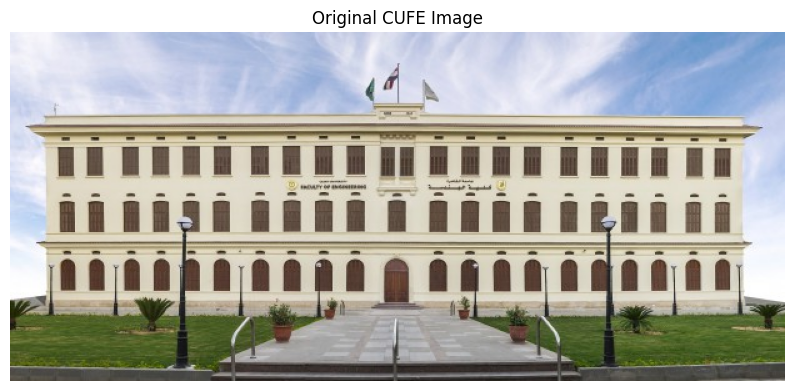

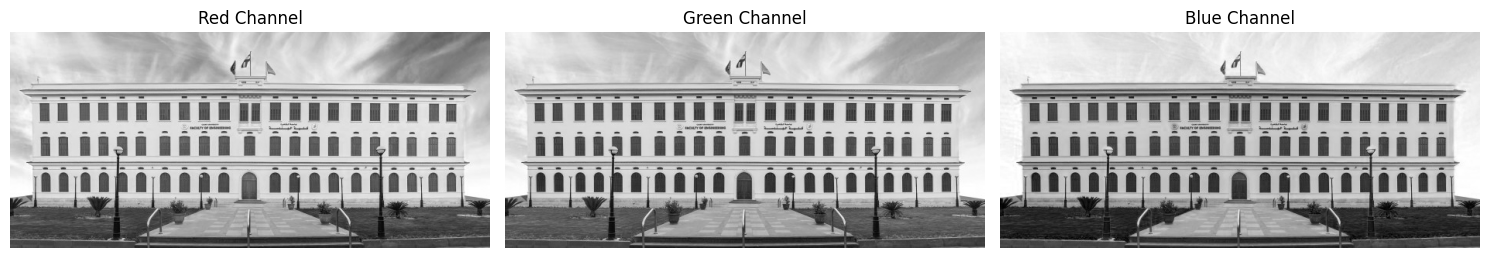

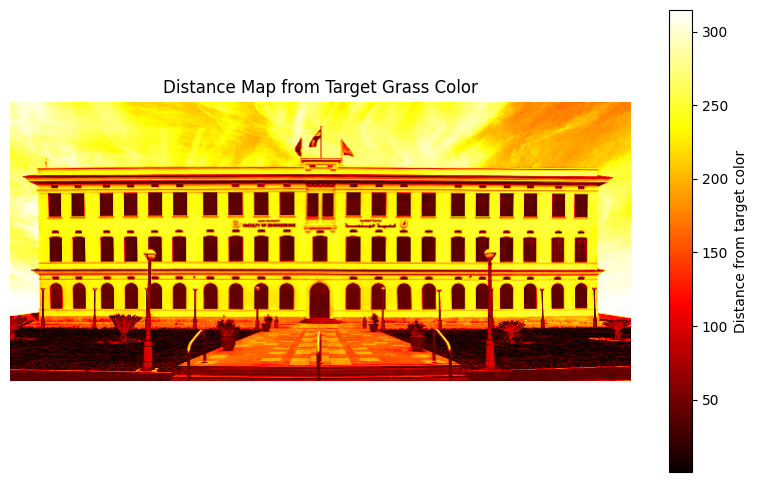

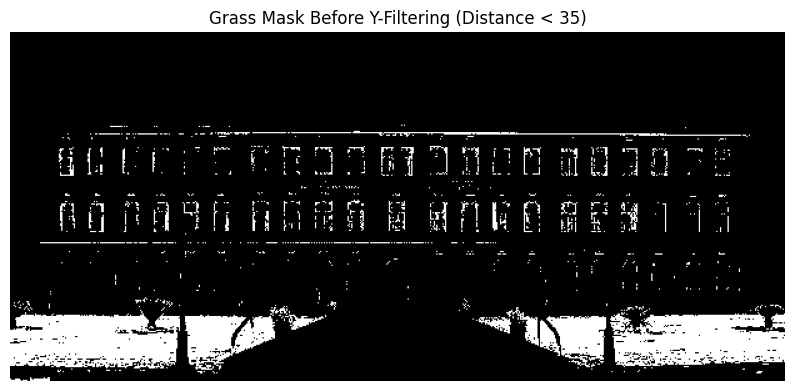

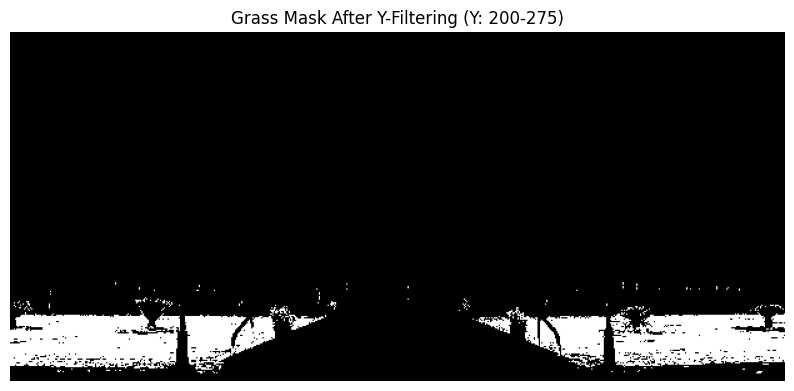

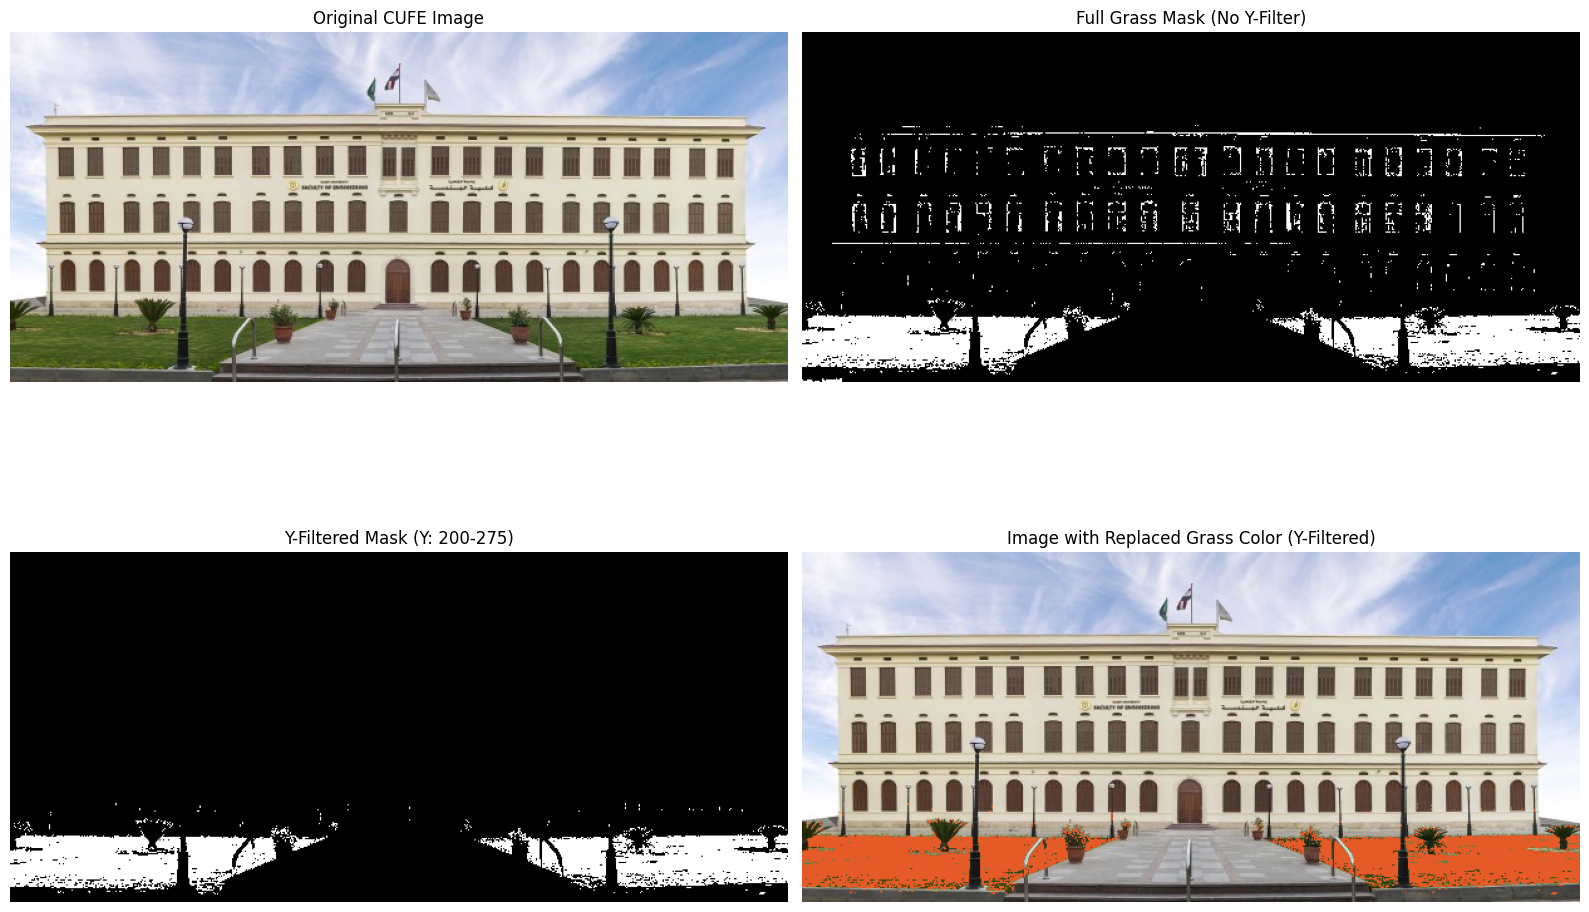

Grass replacement applied only in Y-range: 200 to 275


In [29]:

target_grass_color = np.array([80, 102, 43])  

cufe_image = io.imread('imgs/exp2/cufe.png')
cufe_image = cufe_image.astype(float)

plt.figure(figsize=(10, 6))
plt.imshow(cufe_image.astype(np.uint8))
plt.title('Original CUFE Image')
plt.axis('off')
plt.show()

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.imshow(cufe_image.astype(np.uint8))
# ax.set_title('Original Image with Y-axis (to select grass region)')
# # Add horizontal lines at different Y positions for reference
# for y in range(0, cufe_image.shape[0], 50):
#     ax.axhline(y, color='yellow', linestyle='--', alpha=0.3, linewidth=0.5)
#     ax.text(10, y, f'y={y}', color='yellow', fontsize=8, 
#             bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
# plt.show()

R_cufe = cufe_image[:, :, 0]
G_cufe = cufe_image[:, :, 1]
B_cufe = cufe_image[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(R_cufe, cmap='gray')
axes[0].set_title('Red Channel')
axes[0].axis('off')
axes[1].imshow(G_cufe, cmap='gray')
axes[1].set_title('Green Channel')
axes[1].axis('off')
axes[2].imshow(B_cufe, cmap='gray')
axes[2].set_title('Blue Channel')
axes[2].axis('off')
plt.tight_layout()
plt.show()

diff_R = R_cufe - target_grass_color[0]
diff_G = G_cufe - target_grass_color[1]
diff_B = B_cufe - target_grass_color[2]

distance = np.sqrt(diff_R**2 + diff_G**2 + diff_B**2)

# Visualize the distance map
plt.figure(figsize=(10, 6))
plt.imshow(distance, cmap='hot')
plt.colorbar(label='Distance from target color')
plt.title('Distance Map from Target Grass Color')
plt.axis('off')
plt.show()

threshold_distance = 35
mask_grass = distance < threshold_distance

plt.figure(figsize=(10, 6))
plt.imshow(mask_grass, cmap='gray')
plt.title(f'Grass Mask Before Y-Filtering (Distance < {threshold_distance})')
plt.axis('off')
plt.show()


Y_START_RANGE = 200 
Y_END_RANGE = 275

# Create a final mask that is False everywhere
final_grass_mask = np.zeros_like(mask_grass, dtype=bool)

# Copy only the grass pixels that fall within the Y-axis range
final_grass_mask[Y_START_RANGE:Y_END_RANGE, :] = mask_grass[Y_START_RANGE:Y_END_RANGE, :]

plt.figure(figsize=(10, 6))
plt.imshow(final_grass_mask, cmap='gray')
plt.title(f'Grass Mask After Y-Filtering (Y: {Y_START_RANGE}-{Y_END_RANGE})')
plt.axis('off')
plt.show()

result_image = cufe_image.copy()
replacement_color = np.array([230, 90, 40])

result_image[final_grass_mask, 0] = replacement_color[0]  
result_image[final_grass_mask, 1] = replacement_color[1]  
result_image[final_grass_mask, 2] = replacement_color[2]  

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(cufe_image.astype(np.uint8))
axes[0, 0].set_title('Original CUFE Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_grass, cmap='gray')
axes[0, 1].set_title('Full Grass Mask (No Y-Filter)')
axes[0, 1].axis('off')

axes[1, 0].imshow(final_grass_mask, cmap='gray')
axes[1, 0].set_title(f'Y-Filtered Mask (Y: {Y_START_RANGE}-{Y_END_RANGE})')
axes[1, 0].axis('off')

axes[1, 1].imshow(result_image.astype(np.uint8))
axes[1, 1].set_title('Image with Replaced Grass Color (Y-Filtered)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# # Visualize the Y-range on original image
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.imshow(cufe_image.astype(np.uint8))
# ax.axhline(Y_START_RANGE, color='yellow', linestyle='--', linewidth=2, label=f'Y Start: {Y_START_RANGE}')
# ax.axhline(Y_END_RANGE, color='red', linestyle='--', linewidth=2, label=f'Y End: {Y_END_RANGE}')
# ax.set_title('Y-Axis Range Visualized on Original Image')
# ax.legend()
# ax.axis('off')
# plt.show()

print(f"Grass replacement applied only in Y-range: {Y_START_RANGE} to {Y_END_RANGE}")